# Tidy Data Project

Scenario: The dataset I am working with contains Olympic medalists in the year 2008, but it is not stored in tidy format. The athlete names are listed in one column, while the other columns combine multiple variables such as gender and sport.

Objective:
The goal of this project is to reshape the dataset into tidy format so that:
- each variable has its own column,
- each observation has its own row,
- and the data is easier to analyze and visualize.

In [2]:
# Import the dataset and libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("medalists_data.csv")
df.head()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Original (Untidy) Data:

The dataset is currently in a wide format, where multiple variables (gender and sport) are combined into the column names, and medal outcomes are stored as values in the cells.

According to tidy data principles, each variable should have its own column and each observation should have its own row. This dataset does not follow those principles, so it needs to be reshaped before analysis.

Therefore, this format is not tidy because:
- gender and sport are stored together in the column names,
- medal type is stored as cell values,
- and many cells contain missing values, which are showing up as NaN.

In [3]:
tidy_df = df.melt(
    id_vars = "medalist_name",
    var_name = "gender_sport",
    value_name = "medal"
)

tidy_df.head()

,medalist_name,gender_sport,medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN


## Reshaping the Data:

I used the 'melt()' function from pandas to convert the dataset from wide format to long format, by gathering multiple columns into a single column. This makes the combined column names easier to separate into individual variables.

This step creates a new column that contains combined information about gender and sport, which will be separated in the next step.

In [4]:
tidy_df = tidy_df.dropna(subset=["medal"])
tidy_df.head()  

,medalist_name,gender_sport,medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold


## Drop Missing Values:

After melting the dataset, the data is still untidy since many rows contained missing values. This is because each athlete only appears in the sport and gender category where they won a medal. I removed these missing values so that only valid medal observations remain, by using the 'drop' function. Missing values in this dataset represent categories where an athlete did not win a medal. Therefore, instead of filling these values with 0, I removed them using dropna() so that only valid medal observations remain.

In [5]:
tidy_df[["gender", "sport"]] = tidy_df["gender_sport"].str.split("_", n=1, expand=True)
tidy_df["sport"] = tidy_df["sport"].str.replace("_", " ", regex=False)
tidy_df.head()

tidy_df = tidy_df[["medalist_name", "gender", "sport", "medal"]]
tidy_df.head()

,medalist_name,gender,sport,medal
177,Bair Badënov,male,archery,bronze
676,Ilario Di Buò,male,archery,silver
682,Im Dong-hyun,male,archery,gold
760,Jiang Lin,male,archery,bronze
920,Lee Chang-hwan,male,archery,gold


## Separating Variables:

The column created during the melt process contained both gender and sport information combined into a single column. 

Using 'str.split()', I separated this column into two new variables: 'gender' and 'sport'. I then used 'str.replace()' to clean the sport names and improve readability, since our goal is to have the cleanest, most organized data possible to display.

This step ensures that each variable is stored in its own column, which is a key requirement of tidy data.

## Tidy Data Result:

The dataset is now in tidy format:
- Each variable (medalist name, gender, sport, medal) has its own column
- Each row represents a single observation (one athlete winning one medal)
- The dataset is now structured and organized for efficient analysis and visualization

To sum it all up in a key takeaway, the steps up till now lead us to each row now representing one observation: one athlete winning one medal in one sport category. This structure follows the tidy data principles (Hadley Wickham).

In [6]:
pivot_table = pd.pivot_table(
    tidy_df,
    index='sport',
    columns='medal',
    values='medalist_name',
    aggfunc='count',
    fill_value=0
)

pivot_table

medal,bronze,gold,silver
sport,,,
archery,8,5,7
artistic gymnastics,19,14,16
association football,36,37,36
athletics,55,52,59
badminton,7,7,8
baseball,24,24,24
basketball,24,23,24
beach volleyball,4,4,4
bmx,2,2,2


## Pivot Table Analysis:

To summarize the cleaned dataset, I created a pivot table using 'pd.pivot_table()'. This table counts the number of medal observations for each sport, grouped by medal type (gold, silver, bronze). Pivot tables are useful for aggregating and comparing data across categories. 

In this case, it makes it easier to compare how medals are distributed across sports. In other words, this counts how many gold, silver, and bronze medals appear for each sport.

## Visualizations:

After cleaning the dataset into tidy format, I created visualizations to better understand patterns in the medal data. Because each variable is stored in its own column, it is now easy to group, count, and visualize relationships such as the distribution of medals and the most common sports. 

The following charts summarize which sports appear most often in the dataset and how medal types are distributed across observations.

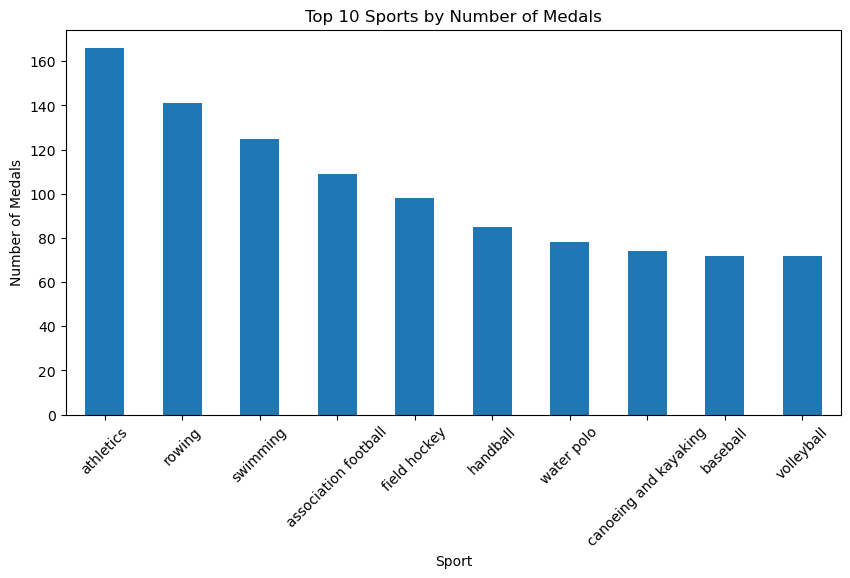

In [7]:
# Visualization 1: Top 10 Sports by Number of Medals

import matplotlib.pyplot as plt
import seaborn as sns

sport_counts = tidy_df["sport"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sport_counts.plot(kind="bar")
plt.title("Top 10 Sports by Number of Medals")
plt.xlabel("Sport")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.show()

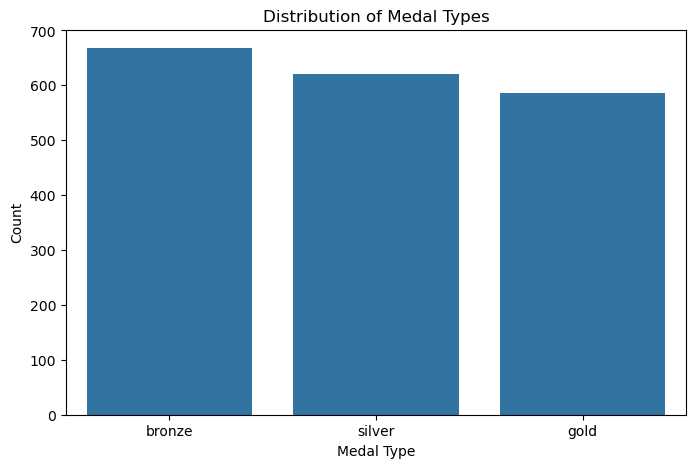

In [8]:
# Visualization 2: Medal Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=tidy_df, x="medal")
plt.title("Distribution of Medal Types")
plt.xlabel("Medal Type")
plt.ylabel("Count")
plt.show()

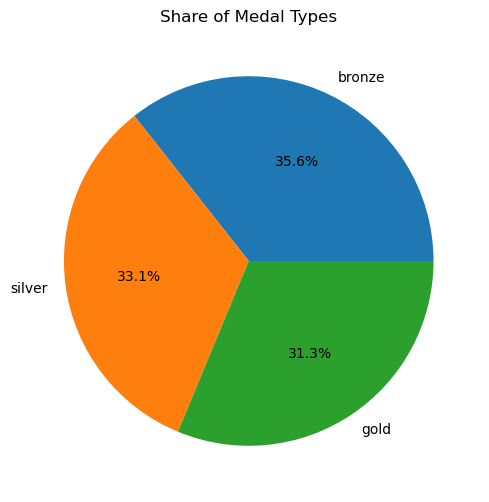

In [9]:
# Visualization 3: Share of Medal Types

medal_counts = tidy_df["medal"].value_counts()

plt.figure(figsize=(6, 6))
medal_counts.plot.pie(
    autopct="%1.1f%%",
    ylabel=""
)
plt.title("Share of Medal Types")
plt.show()

Although all three visualizations summarize the dataset, they were created using slightly different approaches depending on the goal. For the top sports chart, I first calculated the counts using value_counts() and then plotted them using pandas/matplotlib. For the medal distribution bar chart, I used seaborn’s countplot() because it automatically counts the occurrences of each category directly from the dataset. This shows two different approaches to creating similar visualizations depending on the situation.

To provide a different perspective, I also created a pie chart showing the share (percentage) of each medal type. While the bar chart focuses on comparing counts, the pie chart emphasizes the relative proportions of gold, silver, and bronze medals in the dataset. This demonstrates how different visualization types can highlight different aspects of the same data.

## Key Insights:

The visualizations show that certain sports consistently dominate in total medal counts, suggesting they have more events or broader participation. Additionally, the distribution of medal types is relatively balanced, indicating that the dataset represents a wide range of outcomes rather than being skewed toward a specific medal type. 

Specifically: 
- Athletics, rowing, and swimming dominate medal counts, indicating these are the most represented or competitive sports.
- Bronze medals slightly outnumber silver and gold, suggesting a natural distribution where more athletes reach lower podium positions.
- The distribution of medal types is relatively balanced, but gold medals are the least frequent, reflecting their higher difficulty.

Overall, the dataset shows both sport-specific dominance and a predictable hierarchy in medal distribution. Organizing the data into tidy format made it much easier to uncover these patterns and compare categories effectively.


## Takeaway: 

These visualizations demonstrate how transforming the dataset into tidy format makes analysis more straightforward. By organizing the data properly, it becomes easier to summarize and interpret patterns across different variables.